# Exploratory Data Analysis on Diamonds Dataset
##BT23CSE198
### LAB EVAL 1

###Importing Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

###Importing the Dataset

In [ ]:
df = pd.read_csv(r'/content/diamonds.csv')
df

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...,...
53935,53936,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,53937,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,53938,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,53939,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


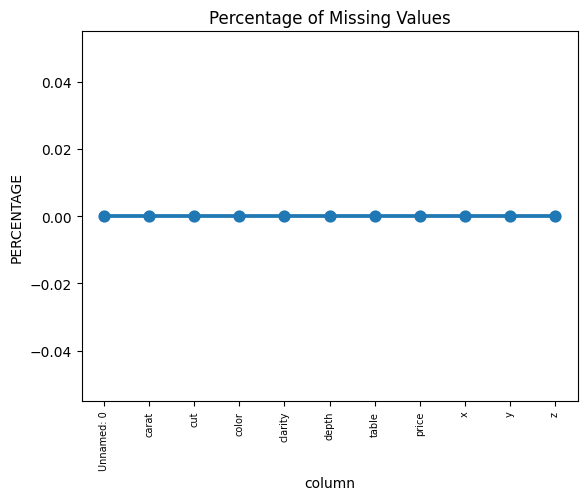

In [ ]:
missing = pd.DataFrame((df.isnull().sum()) * 100 / df.shape[0]).reset_index()
missing.columns = ['column', 'percentage']

# Plot the missing values
ax = sns.pointplot(x='column', y='percentage', data=missing)
plt.xticks(rotation=90, fontsize=7)
plt.title("Percentage of Missing Values")
plt.ylabel("PERCENTAGE")
plt.show()

In [ ]:
df.dtypes


,0
Unnamed: 0,int64
carat,float64
cut,object
color,object
clarity,object
depth,float64
table,float64
price,int64
x,float64
y,float64


## Dataset Overview

1.   The dataset contains 53,940 entries with 11 columns, including numerical and categorical features.

---


2.   **The numerical variables are:**
* **carat** (Weight of the diamond)
* **depth** (The Height of a Diamond, measured from the Culet to the table, divided by its average Girdle Diameter.)
* **table** (Width of top of diamond relative to widest point)
* **price**
* **x, y, z** (dimensions of the diamond in mm).



---


3. **The categorical variables are:**

*   cut (Diamond quality)
*   color (Diamond color grade)
* clarity (Diamond clarity grade)



---


4.   The "Unnamed: 0" column is redundant because we already have an index. We can drop it to clean the dataset.






In [ ]:
df.drop('Unnamed: 0', axis=1, inplace=True)
df

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [ ]:
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


##Observations


1. The minimum price is 326, and the maximum price reaches 18,823, suggesting significant price variation.
2. Minimum values for x, y, and z are 0, which is not physically possible for a diamond.
3. This suggests missing data, so these rows should be dropped for accurate analysis.


####Locating the rows with either of x, y or z equal to zero.

In [ ]:
df.loc[(df['x']==0) | (df['y']==0) | (df['z']==0)]

,carat,cut,color,clarity,depth,table,price,x,y,z
2207,1.00,Premium,G,SI2,59.1,59.0,3142,6.55,6.48,0.0
2314,1.01,Premium,H,I1,58.1,59.0,3167,6.66,6.60,0.0
4791,1.10,Premium,G,SI2,63.0,59.0,3696,6.50,6.47,0.0
5471,1.01,Premium,F,SI2,59.2,58.0,3837,6.50,6.47,0.0
10167,1.50,Good,G,I1,64.0,61.0,4731,7.15,7.04,0.0
11182,1.07,Ideal,F,SI2,61.6,56.0,4954,0.00,6.62,0.0
11963,1.00,Very Good,H,VS2,63.3,53.0,5139,0.00,0.00,0.0
13601,1.15,Ideal,G,VS2,59.2,56.0,5564,6.88,6.83,0.0
15951,1.14,Fair,G,VS1,57.5,67.0,6381,0.00,0.00,0.0
24394,2.18,Premium,H,SI2,59.4,61.0,12631,8.49,8.45,0.0


In [ ]:
len(df[(df['x']==0) | (df['y']==0) | (df['z']==0)])

20

#### Removing these rows

In [ ]:
df = df[(df[['x','y','z']] != 0).all(axis=1)]

#### Checking if any such row still exists

In [ ]:
len(df[(df['x']==0) | (df['y']==0) | (df['z']==0)])

0

###Checking Missing Values

In [ ]:
df.isnull().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0


####Finding Duplicates

In [ ]:
df.duplicated().sum()

np.int64(145)

Printing duplicates

In [ ]:
print(df[df.duplicated()])


       carat    cut color clarity  depth  table  price     x     y     z
1005    0.79  Ideal     G     SI1   62.3   57.0   2898  5.90  5.85  3.66
1006    0.79  Ideal     G     SI1   62.3   57.0   2898  5.90  5.85  3.66
1007    0.79  Ideal     G     SI1   62.3   57.0   2898  5.90  5.85  3.66
1008    0.79  Ideal     G     SI1   62.3   57.0   2898  5.90  5.85  3.66
2025    1.52   Good     E      I1   57.3   58.0   3105  7.53  7.42  4.28
...      ...    ...   ...     ...    ...    ...    ...   ...   ...   ...
47296   0.30   Good     J     VS1   63.4   57.0    394  4.23  4.26  2.69
47969   0.52  Ideal     D     VS2   61.8   55.0   1919  5.19  5.16  3.20
49326   0.51  Ideal     F    VVS2   61.2   56.0   2093  5.17  5.19  3.17
50079   0.51  Ideal     F    VVS2   61.2   56.0   2203  5.19  5.17  3.17
52861   0.50   Fair     E     VS2   79.0   73.0   2579  5.21  5.18  4.09

[145 rows x 10 columns]


Dupplicates Dropped

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

###Checking for any negative values (Price, carat, depth, table cannot be negative)

In [ ]:
df[df['price']<0].count()
df[df['carat']<0].count()
df[df['depth']<0].count()
df[df['table']<0].count()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0


###Checking the number of unique values for each variable.

In [ ]:
uniqueValues = df.nunique()
uniqueValues

,0
carat,273
cut,5
color,7
clarity,8
depth,184
table,127
price,11597
x,553
y,550
z,374


####Plotting these values.

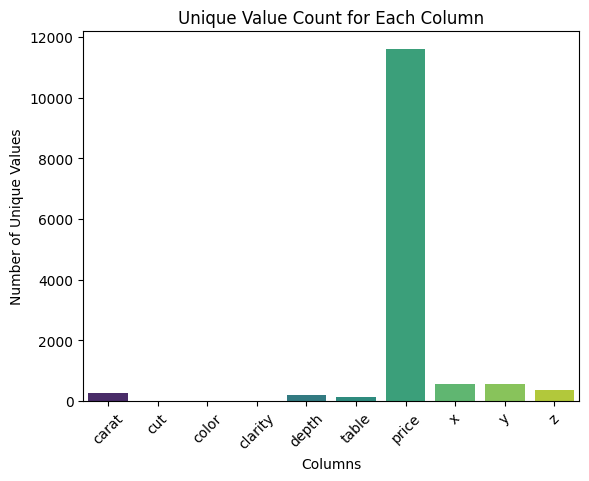

In [ ]:
sns.barplot(x=uniqueValues.index, y=uniqueValues.values, palette='viridis')

plt.xlabel("Columns")
plt.ylabel("Number of Unique Values")
plt.title("Unique Value Count for Each Column")
plt.xticks(rotation=45)
plt.show()

####Observations:
1. The graph clearly shows that there is a huge variation in price.
2. Due to such a big difference in values of other categories in comparison to price, it is hard to observe other categories.
3. We can try takiing log of values for a clear pot.

####Plotting with log values

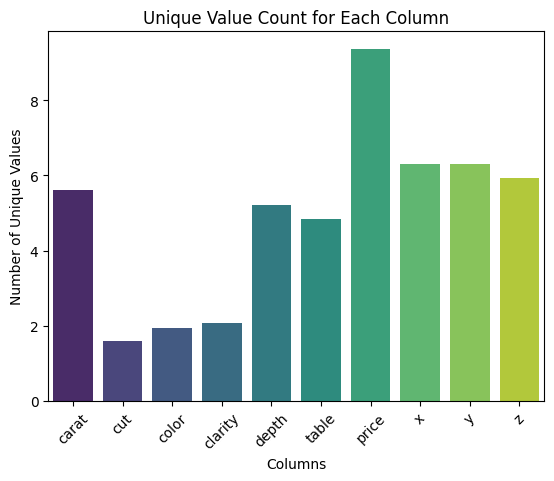

In [ ]:
sns.barplot(x=uniqueValues.index, y=np.log(uniqueValues.values), palette='viridis')

plt.xlabel("Columns")
plt.ylabel("Number of Unique Values")
plt.title("Unique Value Count for Each Column")
plt.xticks(rotation=45)
plt.show()

## Object Datatype

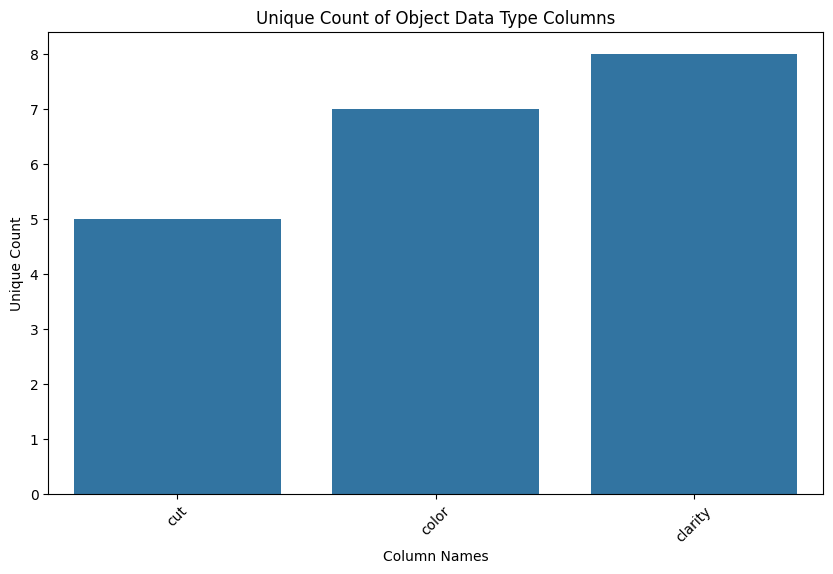

In [ ]:
object_columns = df.select_dtypes(include=['object']).columns
num_columns = df.select_dtypes(include=['int64', 'float64']).columns
# Count the unique values for each object column
unique_counts = df[object_columns].nunique()

# Convert the Series to a DataFrame for easier plotting with Seaborn
unique_counts_df = unique_counts.reset_index()
unique_counts_df.columns = ['Column', 'Unique Count']

# Plotting the graph
plt.figure(figsize=(10, 6))
sns.barplot(x='Column', y='Unique Count', data=unique_counts_df)
plt.xlabel('Column Names')
plt.ylabel('Unique Count')
plt.title('Unique Count of Object Data Type Columns')
plt.xticks(rotation=45)
plt.show()

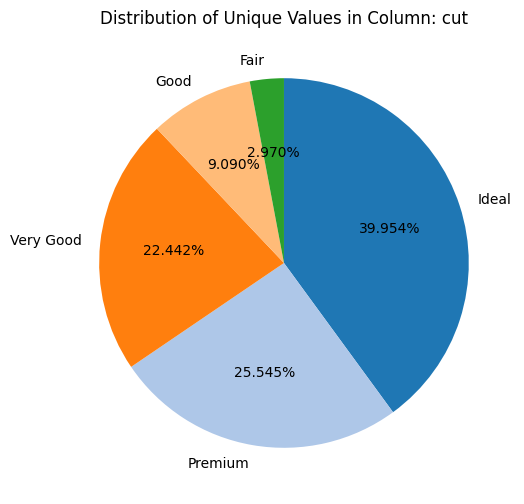

<Figure size 1000x600 with 0 Axes>

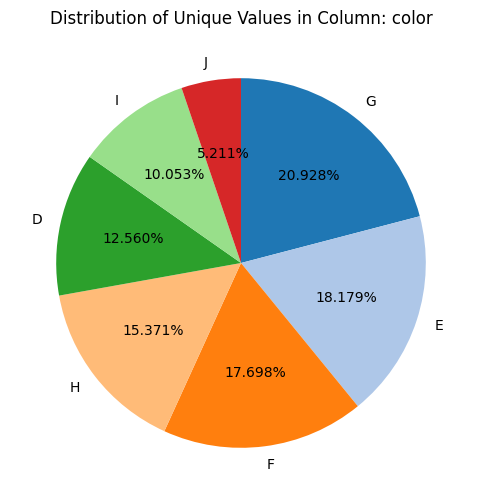

<Figure size 1000x600 with 0 Axes>

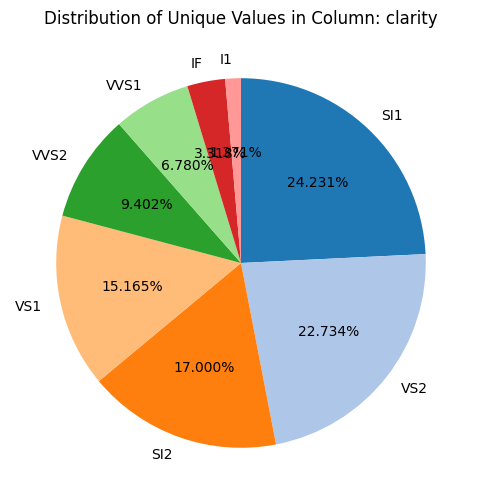

<Figure size 1000x600 with 0 Axes>

In [ ]:
colors = plt.get_cmap('tab20').colors

# Plotting the pie chart for each object column
for column in object_columns:
    plt.figure(figsize=(10, 6))
    df[column].value_counts().plot.pie(autopct='%1.3f%%', startangle=90, counterclock=False, colors=colors)
    plt.ylabel('')
    plt.title(f'Distribution of Unique Values in Column: {column}')
    plt.show()
    plt.gcf().set_size_inches(10, 6)
    plt.gcf().tight_layout(pad=3.0)

## Numerical Datatype

In [ ]:
cuts_freq=df.groupby('cut').size()
print(cuts_freq)

cut
Fair          1597
Good          4888
Ideal        21485
Premium      13737
Very Good    12068
dtype: int64


In [ ]:
clarity_freq=df.groupby('clarity').size()
print(clarity_freq)

clarity
I1        737
IF       1784
SI1     13030
SI2      9142
VS1      8155
VS2     12225
VVS1     3646
VVS2     5056
dtype: int64


In [ ]:
color_freq=df.groupby('color').size()
print(color_freq)

color
D     6754
E     9776
F     9517
G    11254
H     8266
I     5406
J     2802
dtype: int64


###Price by cut, clarity and color

### Calculating average prices based on clarity, color and price.

In [ ]:
#average price based on clarity
clarityVsAveragePrice = df.groupby(['clarity'])['price'].mean().round(2).reset_index()

In [ ]:
#average price based on color
colorVsAveragePrice = df.groupby(['color'])['price'].mean().round(2).reset_index()

In [ ]:
#average price by carat
caratVsAveragePrice = df.groupby(['carat'])['price'].mean().round(2).reset_index()

####Plot for Average price based on Color

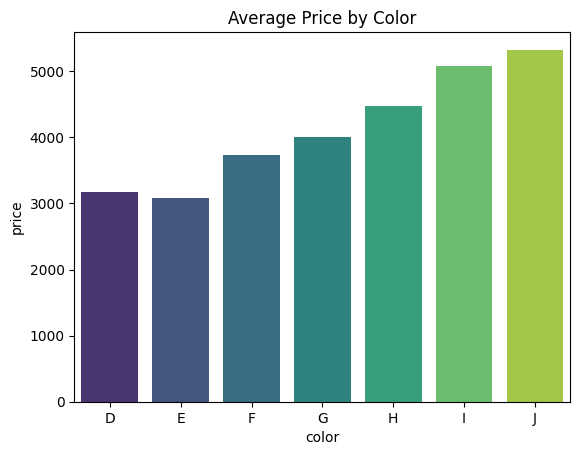

In [ ]:
sns.barplot(data=colorVsAveragePrice, x='color', y='price', palette='viridis')
plt.title("Average Price by Color")
plt.show()

####Plot for Average price based on Clarity

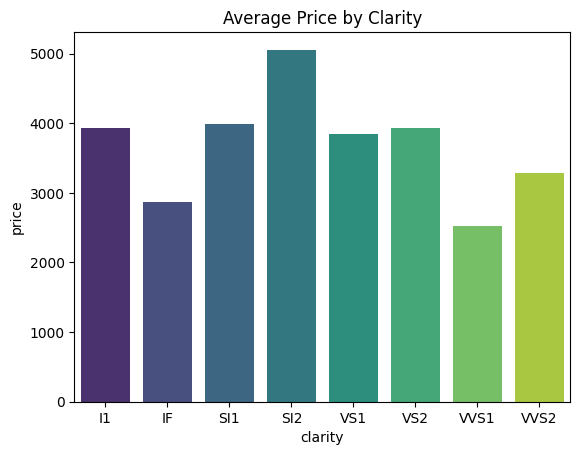

In [ ]:
sns.barplot(data=clarityVsAveragePrice, x='clarity', y='price', palette='viridis')
plt.title("Average Price by Clarity")
plt.show()

####Plot for Average price based on Color

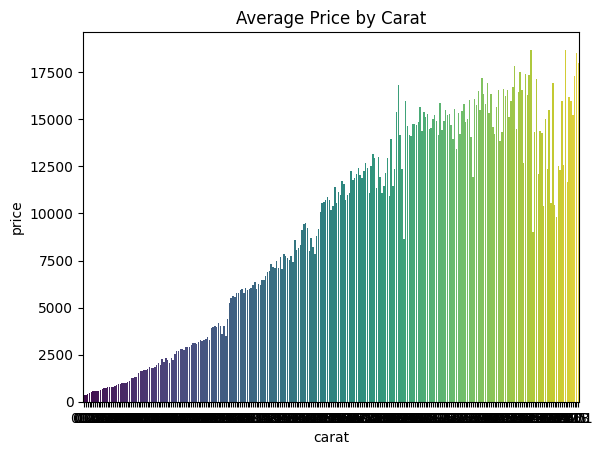

In [ ]:
sns.barplot(data=caratVsAveragePrice, x='carat', y='price', palette='viridis')
plt.title("Average Price by Carat")
plt.show()

####Observations
1. The bar chart shown makes it difficult to distinguish individual data points, especially as carat values increases.
2. Since we have a lot of unique values for carat, a scatter plot prevents overcrowding and allows for better pattern understanding.

####Plotting a scatter plot for it.

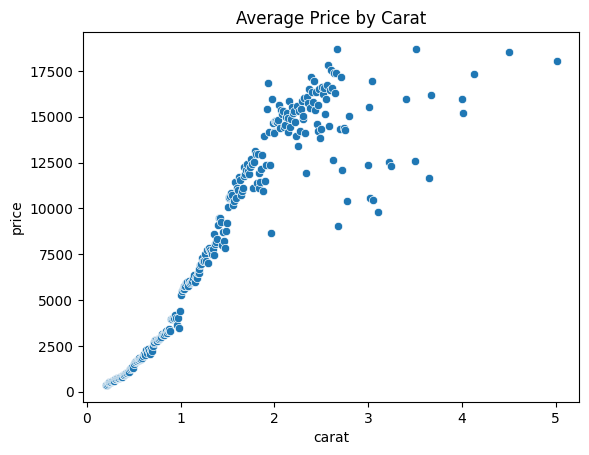

In [ ]:
sns.scatterplot(data=caratVsAveragePrice, x='carat', y='price')
plt.title("Average Price by Carat")
plt.show()



*   As the carat size increases, the average price also increases showing a exponential increase.
*   The price increase is steeper for larger carats (above 1 carat).
*   This suggests that bigger diamonds are much more expensive per carat due to rarity.


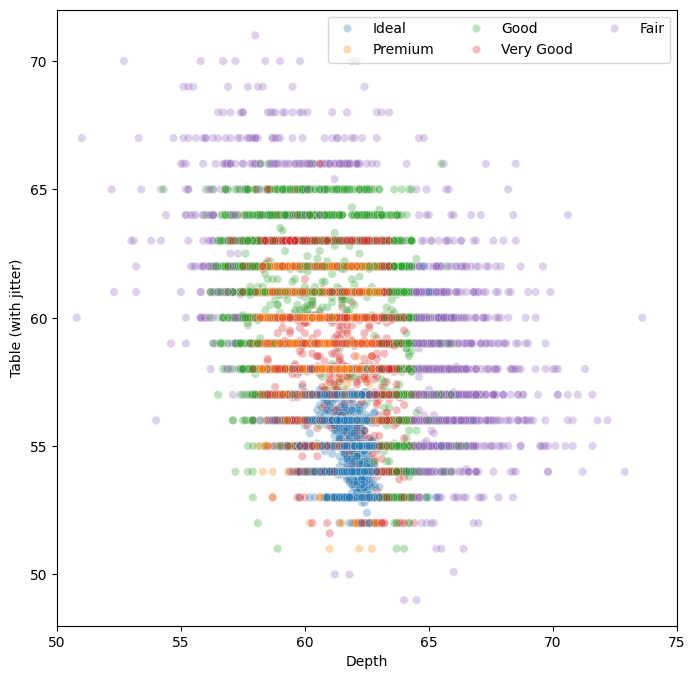

In [ ]:
# df['table_jittered'] = df['table'] + np.random.uniform(-200, 200, size=len(df))

# Create the plot
plt.figure(figsize=(8, 8))
sns.scatterplot(x="depth", y="table", data=df, alpha=.3, hue="cut")
plt.xlabel("Depth")
plt.ylabel("Table (without jitter)")
plt.legend(ncol=3)
plt.xlim(50, 75)
plt.ylim(48, 72)
plt.show()

###Observations:
1. Ideal Cut Diamonds (Blue) - They are concentrated around a depth of 60% and table around 55%, indicating that they tend to follow the standard proportions for optimal brilliance.
2. Premium, Good, and Very Good Cuts (Orange, Green, Red) - These cuts are more spread out but still cluster near the center, suggesting some variability while still adhering to acceptable standards.
3. Fair Cut Diamonds (Purple) - They are more widely dispersed, covering a broader range of depth and table values, indicating that they do not strictly follow ideal proportions.


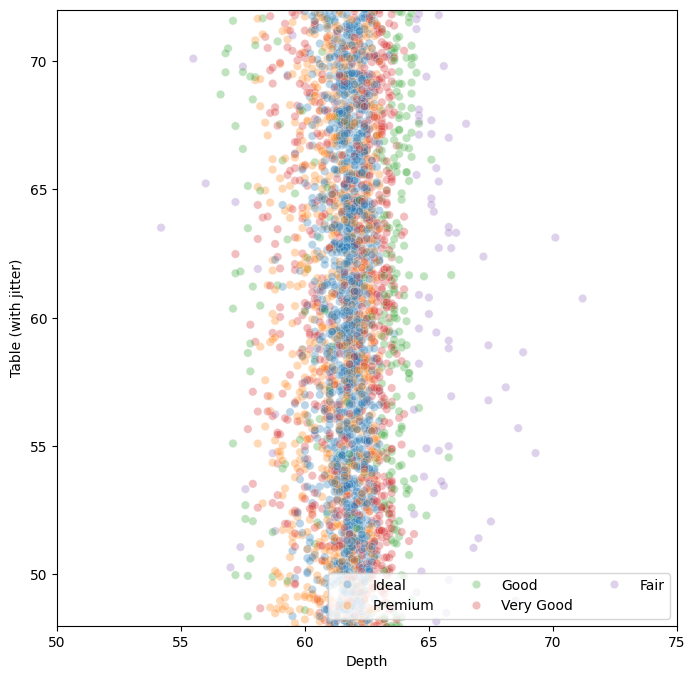

In [ ]:
df['table_jittered'] = df['table'] + np.random.uniform(-200, 200, size=len(df))

# Create the plot
plt.figure(figsize=(8, 8))
sns.scatterplot(x="depth", y="table_jittered", data=df, alpha=.3, hue="cut")
plt.xlabel("Depth")
plt.ylabel("Table (with jitter)")
plt.legend(ncol=3)
plt.xlim(50, 75)
plt.ylim(48, 72)
plt.show()

###Observations
1. **Strong vertical alignment:** This suggests that depth values are more continuous, while table values are more discrete, likely due to standard industry-cut proportions.
2. Most diamonds cluster around a depth of 60-63% and a table of 54-62%, indicating that these ranges are common across all cuts.
3. The spread of different cut types (Ideal, Premium, Good, Very Good, and Fair) is fairly even across depth values, suggesting that depth alone is not a major distinguishing factor among cuts.
4. **Outliers:** A few Fair cut diamonds (purple) extend beyond the usual depth and table range, implying that Fair cut diamonds tend to deviate more from optimal proportions.

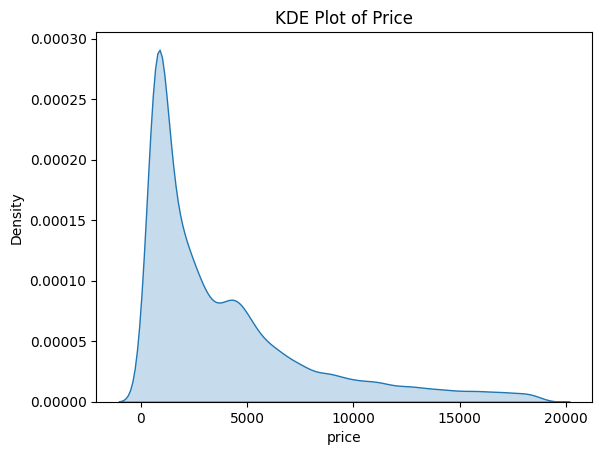

In [ ]:
sns.kdeplot(df['price'], shade=True)
plt.title('KDE Plot of Price')
plt.show()

### Observations
1. The price distribution is highly skewed to the right (positively skewed).
2. Most diamonds have a low price which suggests that cheaper diamonds are much more common than expensive ones.
3. There is a sharp peak at lower price ranges, indicating that most diamonds fall into the affordable category.
4. A gradual decline in density as price increases, meaning a small number of diamonds are very expensive.

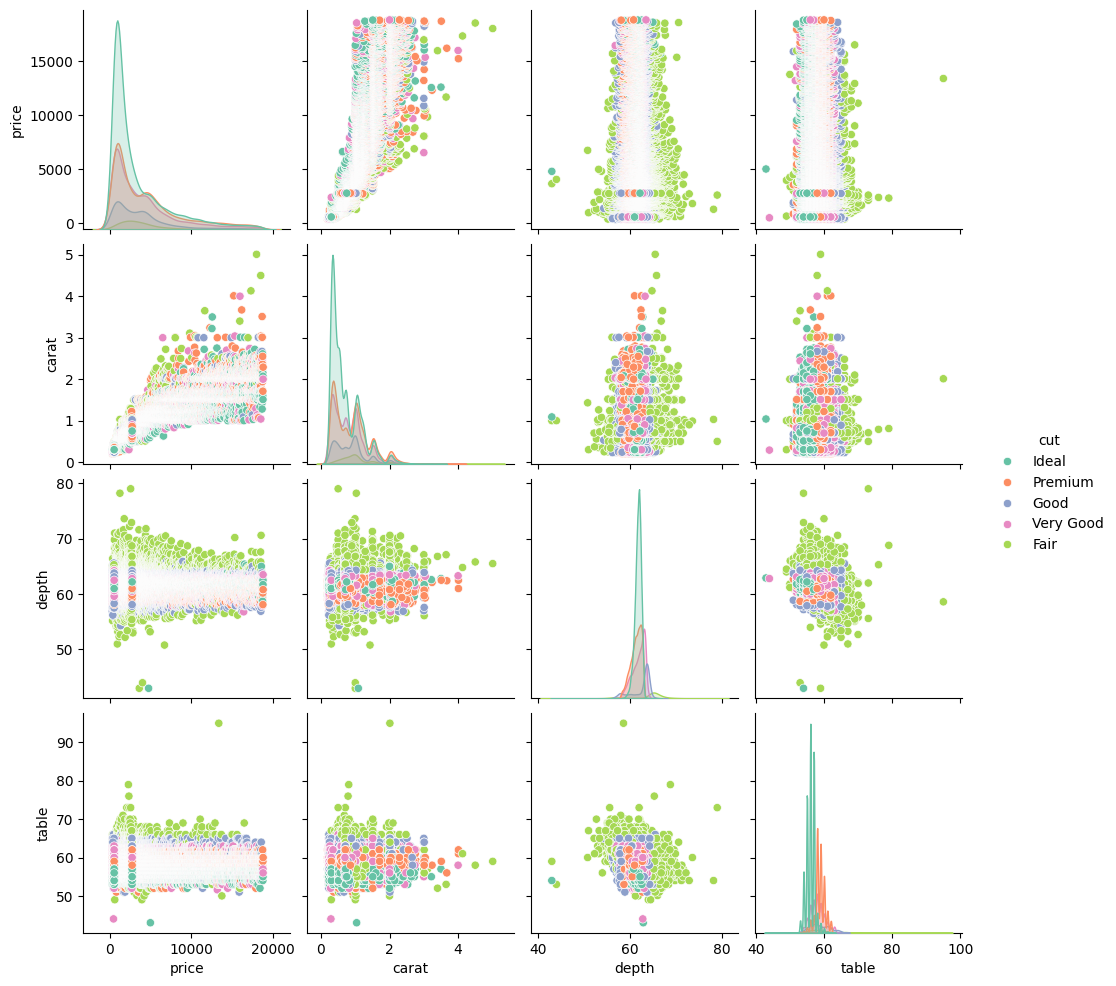

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df, hue="cut", vars=["price", "carat", "depth", "table"], palette="Set2")
plt.show()

###Observations
1. The points are densely packed at lower carat values, meaning most diamonds in the dataset are small.
2. The distribution appears scattered for both depth and table.
3.  Higher cuts (Ideal, Premium) are mostly found in lower carat diamonds.
4. Price values have a right-skewed distribution, meaning a few high-priced diamonds exist but most are on the lower end.

Text(0.5, 1.0, 'Correlation Matrix')

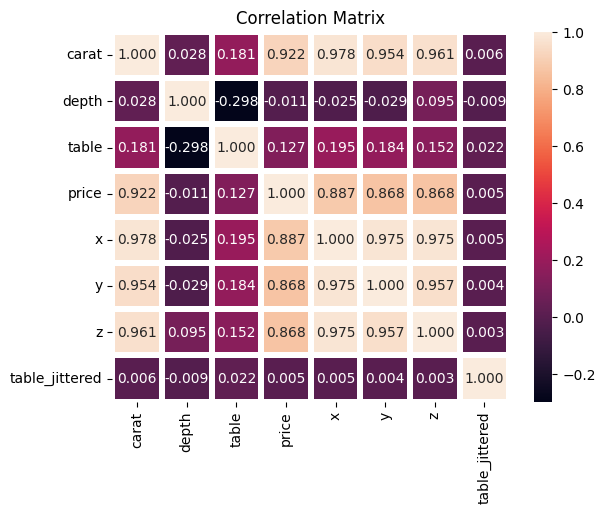

In [ ]:
numericData = df.select_dtypes(include='number')
sns.heatmap(numericData.corr(), annot=True, fmt='.3f',linewidths=3)
plt.title('Correlation Matrix')

###Observations
1. Depth is inversely related to Price.
This is because if a Diamond's Depth percentage is too large or small the Diamond will become 'Dark' in appearance because it will no longer return an Attractive amount of light.
2. The Price of the Diamond is highly correlated to Carat, and its Dimensions.

3. The Weight (Carat) of a diamond has the most significant impact on its Price.
Since, the larger a stone is, the Rarer it is, one 2 carat diamond will be more 'Expensive' than the total cost of two 1 Carat Diamonds of the same Quality.
4. The Length(x) , Width(y) and Height(z) seems to be higly related to Price and even each other.

5. Self Relation ie. of a feature to itself is 1 as expected.

*For better corelation of the dimensions with the price of diamond we can add one more column for the estimate volume of the diamond.

In [ ]:
df['volume'] = df['x']*df['y']*df['z']
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z,table_jittered,volume
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,231.981111,38.202030
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,11.011738,34.505856
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,-46.517540,38.076885
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,138.329840,46.724580
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,-113.196047,51.917250


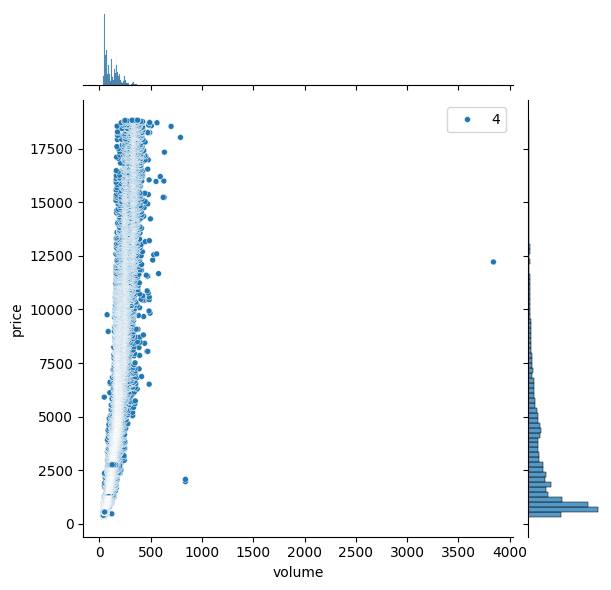

In [ ]:
sns.jointplot(x='volume', y='price' , data=df, size=4)

###Observation
1. It seems that there is linear relationship between price and volume(x\*y\*z).

Text(0.5, 1.0, 'Correlation Matrix')

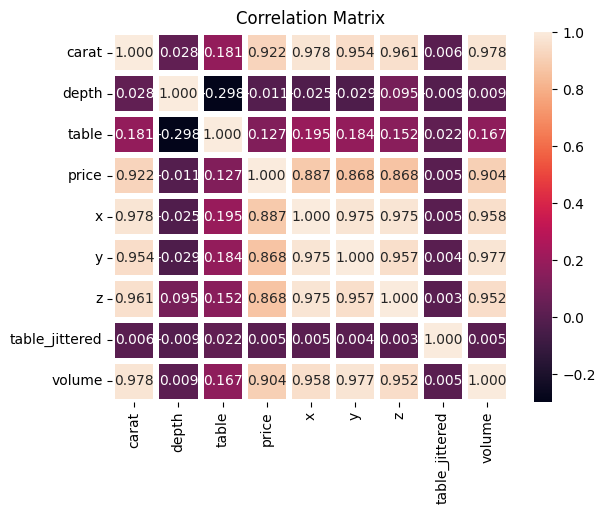

In [ ]:
numericData = df.select_dtypes(include='number')
sns.heatmap(numericData.corr(), annot=True, fmt='.3f',linewidths=3)
plt.title('Correlation Matrix')

It is easier now to visualize the corelation between diamonds size and other factors.
###Observations
1. Volume is highly correlated with carat (0.978) and price (0.904) which is obvious as volume is naturally expected to grow with carat, reinforcing the correlation.
2. Depth has very weak correlation with price (-0.011) and that to reverse.
3. Table has a weak correlation with price (0.127)
4. Depth and Table show some negative correlations with other features. For example,
Depth vs Table (-0.298) As depth increases, the table size tends to decrease.



---



# Conclusion
####1. Carat plays the most crucial role in determining a diamond's price.
####2. Volume is strongly correlated with price and can serve as a key predictive feature.
####3. Depth and table have a negligible influence on price.
####4. The dataset is predominantly composed of smaller, lower-priced diamonds, with a few high-value outliers.
